# Proyecto Final Machine Learning Clasico
## Prediccion de Demanda · Tienda de Ropa Medellin
---
**Dataset resuelto con todos los ejercicios completados.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
from datetime import datetime
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
import xgboost  as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Librerias listas')

/home/karlos/Downloads/Local Send/IA_ROPA/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1779048399.901716  147577 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779048399.939069  147577 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779048400.936838  147577 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Librerias listas


## Seccion 1 · Ejercicio 1 — Diccionario de dtypes

In [2]:
DTYPES = {
    'venta_id'        : 'int32',
    'hora'            : 'int8',
    'estrato'         : 'int8',
    'tienda_id'       : 'category',
    'nombre_tienda'   : 'category',
    'centro_comercial': 'category',
    'barrio'          : 'category',
    'producto_id'     : 'category',
    'nombre_producto' : 'category',
    'categoria'       : 'category',
    'genero_objetivo' : 'category',
    'talla'           : 'category',
    'color'           : 'category',
    'metodo_pago'     : 'category',
    'cantidad'        : 'int8',
    'precio_unitario' : 'int32',
    'descuento_pct'   : 'int8',
    'precio_final'    : 'int32',
    'es_liquidacion'  : 'int8',
    'liq_enero'       : 'int8',
    'liq_julio'       : 'int8',
    'es_dia_madre'    : 'int8',
    'es_amor_amistad' : 'int8',
    'es_dia_padre'    : 'int8',
    'es_feria_flores' : 'int8',
    'es_diciembre'    : 'int8',
    'es_festivo'      : 'int8',
}

RUTA_DATASET = 'ropa_medellin.csv'  # ajusta la ruta segun tu entorno
t0 = datetime.now()
df = pd.read_csv(RUTA_DATASET, parse_dates=['fecha'], dtype=DTYPES)
print(f'Listo en {(datetime.now()-t0).seconds}s | Shape: {df.shape}')
print(f'Memoria: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
df.head(3)

Listo en 4s | Shape: (3724486, 28)
Memoria: 156.3 MB


,venta_id,fecha,hora,tienda_id,nombre_tienda,centro_comercial,barrio,estrato,producto_id,nombre_producto,...,metodo_pago,es_liquidacion,liq_enero,liq_julio,es_dia_madre,es_amor_amistad,es_dia_padre,es_feria_flores,es_diciembre,es_festivo
0,1,2021-01-01,19,R01,Coleccion El Tesoro,El Tesoro,El Poblado,5,J003,Cardigan tejido,...,Debito,1,1,0,0,0,0,0,0,1
1,2,2021-01-01,19,R01,Coleccion El Tesoro,El Tesoro,El Poblado,5,C002,Blusa estampada mujer,...,Credito,1,1,0,0,0,0,0,0,1
2,3,2021-01-01,18,R01,Coleccion El Tesoro,El Tesoro,El Poblado,5,D003,Chaqueta rompevientos,...,Credito,1,1,0,0,0,0,0,0,1


## Seccion 2 · Ejercicio 2 — Patrones de moda

Impacto Dia de la Madre:
                      mean    count
Semana normal     117231.0  3552601
Semana Dia Madre  133959.0   171885

Rotacion total (unidades vendidas):
categoria
Pantalones          1142597
Camisetas y Tops    1082755
Ropa Interior        788347
Accesorios           668904
Calzado              595124
Vestidos             593658
Chaquetas            533555
Deportiva            446843
Name: cantidad, dtype: int64

Precio promedio por CC:
                      mean   count
centro_comercial                  
El Tesoro         173342.0  501010
Santafe           139373.0  567439
Mayorca           133943.0  598032
Los Molinos       111575.0  663122
Unico Itagui       87144.0  745309
Puerta del Norte   83944.0  649574


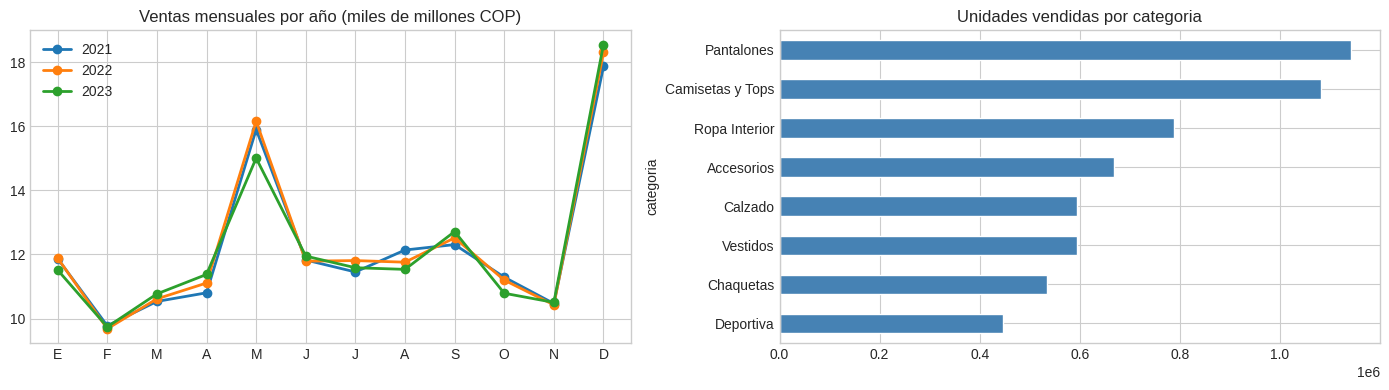

In [3]:
# 2a. Impacto del Dia de la Madre
impacto_madre = df.groupby('es_dia_madre')['precio_final'].agg(['mean','count'])
impacto_madre.index = ['Semana normal','Semana Dia Madre']
print('Impacto Dia de la Madre:')
print(impacto_madre.round(0))

# 2b. Rotacion por categoria
rotacion = df.groupby('categoria')['cantidad'].sum().sort_values(ascending=False)
print('\nRotacion total (unidades vendidas):')
print(rotacion)

# 2c. Ventas mensuales por año
df['_anio'] = df['fecha'].dt.year
df['_mes']  = df['fecha'].dt.month
ventas_mes  = df.groupby(['_anio','_mes'])['precio_final'].sum().reset_index()
ventas_mes.columns = ['anio','mes','ventas']
df.drop(columns=['_anio','_mes'], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for anio, g in ventas_mes.groupby('anio'):
    axes[0].plot(g['mes'], g['ventas']/1e9, marker='o', label=str(anio), lw=2)
axes[0].set_title('Ventas mensuales por año (miles de millones COP)')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].legend()

# 2d. CC con mayor precio promedio
precio_cc = df.groupby('centro_comercial')['precio_final'].agg(['mean','count']).sort_values('mean',ascending=False)
print('\nPrecio promedio por CC:')
print(precio_cc.round(0))

rotacion.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Unidades vendidas por categoria')
plt.tight_layout()
plt.show()

## Seccion 3 · Ejercicio 3 — Feature Engineering

In [4]:
df['anio']              = df['fecha'].dt.year.astype('int16')
df['mes']               = df['fecha'].dt.month.astype('int8')
df['dia_semana']        = df['fecha'].dt.dayofweek.astype('int8')
df['trimestre']         = df['fecha'].dt.quarter.astype('int8')
df['es_finde']          = (df['dia_semana'] >= 5).astype('int8')
df['dias_desde_inicio'] = (df['fecha'] - df['fecha'].min()).dt.days.astype('int16')

condiciones = [
    df['es_liquidacion'] == 1,
    (df['es_dia_madre']==1) | (df['es_amor_amistad']==1) | (df['es_dia_padre']==1),
    df['es_diciembre'] == 1
]
opciones = [1, 2, 3]
df['temporada_moda']  = np.select(condiciones, opciones, default=0).astype('int8')
df['nivel_descuento'] = pd.cut(
    df['descuento_pct'], bins=[-1, 0, 15, 29, 100], labels=[0, 1, 2, 3]
).astype('int8')

print('Distribucion temporada_moda:')
print(df['temporada_moda'].value_counts().sort_index())
print('\n0=Regular  1=Liquidacion  2=Evento  3=Diciembre')

Distribucion temporada_moda:
temporada_moda
0    1981334
1     969996
2     364301
3     408855
Name: count, dtype: int64

0=Regular  1=Liquidacion  2=Evento  3=Diciembre


## Seccion 3 · Ejercicio 4 — Target ventas semanales

In [5]:
demanda_diaria = (
    df.groupby(['fecha','tienda_id','categoria'])
    .agg(
        items_dia  = ('cantidad',      'sum'),
        ingresos   = ('precio_final',  'sum'),
        n_ventas   = ('venta_id',      'count'),
        desc_prom  = ('descuento_pct', 'mean')
    )
    .reset_index()
)

demanda_diaria['anio']              = demanda_diaria['fecha'].dt.year.astype('int16')
demanda_diaria['mes']               = demanda_diaria['fecha'].dt.month.astype('int8')
demanda_diaria['dia_semana']        = demanda_diaria['fecha'].dt.dayofweek.astype('int8')
demanda_diaria['trimestre']         = demanda_diaria['fecha'].dt.quarter.astype('int8')
demanda_diaria['es_finde']          = (demanda_diaria['dia_semana'] >= 5).astype('int8')
demanda_diaria['dias_desde_inicio'] = (
    (demanda_diaria['fecha'] - demanda_diaria['fecha'].min()).dt.days.astype('int16')
)

le_t = {t:i for i,t in enumerate(demanda_diaria['tienda_id'].unique())}
le_c = {c:i for i,c in enumerate(demanda_diaria['categoria'].unique())}
demanda_diaria['tienda_enc']    = demanda_diaria['tienda_id'].map(le_t).astype('int8')
demanda_diaria['categoria_enc'] = demanda_diaria['categoria'].map(le_c).astype('int8')

demanda_diaria = demanda_diaria.sort_values(['tienda_id','categoria','fecha'])
demanda_diaria['target_7d'] = (
    demanda_diaria
    .groupby(['tienda_id','categoria'])['items_dia']
    .transform(lambda x: x.rolling(7, min_periods=7).sum().shift(-7))
)
demanda_diaria = demanda_diaria.dropna(subset=['target_7d']).reset_index(drop=True)
print(f'Dataset para ML: {len(demanda_diaria):,} filas')
print(f'Target promedio: {demanda_diaria["target_7d"].mean():.1f} items/semana')

Dataset para ML: 52,224 filas
Target promedio: 775.6 items/semana


In [6]:
FEATURES = ['anio','mes','dia_semana','trimestre','es_finde',
            'dias_desde_inicio','tienda_enc','categoria_enc',
            'items_dia','ingresos','n_ventas','desc_prom']
TARGET = 'target_7d'

X = demanda_diaria[FEATURES]
y = demanda_diaria[TARGET]
fecha_corte = demanda_diaria['fecha'].max() - pd.Timedelta(days=90)
mask_train  = demanda_diaria['fecha'] <= fecha_corte
X_train, X_test = X[mask_train].copy(), X[~mask_train].copy()
y_train, y_test = y[mask_train].copy(), y[~mask_train].copy()
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 47,904 | Test: 4,320


## Seccion 5 · Ejercicio 5 — Baseline Ridge

In [7]:
kf = KFold(n_splits=10, shuffle=False)
modelo_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=100))
])
scores = cross_val_score(modelo_ridge, X_train, y_train, cv=kf, scoring='r2')
print(f'Ridge R2-CV: {scores.mean():.4f} +/- {scores.std():.4f}')

modelo_ridge.fit(X_train, y_train)
y_pred_base = modelo_ridge.predict(X_test)
r2_base   = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
print(f'BASELINE TEST: R2={r2_base:.4f} | RMSE={rmse_base:.2f} | MAE={mae_base:.2f}')
RESULTADOS = {'baseline': {'r2':r2_base,'rmse':rmse_base,'mae':mae_base}}

Ridge R2-CV: 0.5358 +/- 0.0453
BASELINE TEST: R2=0.6467 | RMSE=188.28 | MAE=145.03


## Secciones 6-8 · Ejercicios 6, 7, 8 — Optuna

In [8]:
FRAC    = 0.15
idx_opt = np.random.RandomState(SEED).choice(len(X_train), int(len(X_train)*FRAC), replace=False)
X_opt, y_opt = X_train.iloc[idx_opt], y_train.iloc[idx_opt]
print(f'Submuestra: {len(X_opt):,} filas')

Submuestra: 7,185 filas


In [9]:
# Ejercicio 6 — Random Forest
def objetivo_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt','log2',0.5]),
        'max_samples'      : trial.suggest_float('max_samples', 0.5, 1.0),
        'random_state': SEED, 'n_jobs': -1
    }
    scores = cross_val_score(RandomForestRegressor(**params), X_opt, y_opt,
                             cv=KFold(3, shuffle=False), scoring='r2', n_jobs=1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objetivo_rf, n_trials=80, timeout=14400, show_progress_bar=True)
print(f'Mejor R2 RF: {study_rf.best_value:.4f}')

Best trial: 52. Best value: 0.796841: 100%|██████████| 80/80 [00:56<00:00,  1.41it/s, 56.86/14400 seconds]

Mejor R2 RF: 0.7968


In [10]:
# Ejercicio 7 — XGBoost
def objetivo_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 400),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0
    }
    scores = cross_val_score(xgb.XGBRegressor(**params), X_opt, y_opt,
                             cv=KFold(3, shuffle=False), scoring='r2', n_jobs=1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objetivo_xgb, n_trials=80, timeout=9000, show_progress_bar=True)
print(f'Mejor R2 XGB: {study_xgb.best_value:.4f}')

Best trial: 72. Best value: 0.931891: 100%|██████████| 80/80 [00:39<00:00,  2.04it/s, 39.16/9000 seconds]

Mejor R2 XGB: 0.9319


In [11]:
# Ejercicio 8 — LightGBM
def objetivo_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 400),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': SEED, 'n_jobs': -1, 'verbosity': -1
    }
    scores = cross_val_score(lgb.LGBMRegressor(**params), X_opt, y_opt,
                             cv=KFold(3, shuffle=False), scoring='r2', n_jobs=1)
    return scores.mean()

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(objetivo_lgbm, n_trials=80, timeout=5400, show_progress_bar=True)
print(f'Mejor R2 LGBM: {study_lgbm.best_value:.4f}')

Best trial: 73. Best value: 0.934112: 100%|██████████| 80/80 [00:57<00:00,  1.39it/s, 57.51/5400 seconds]

Mejor R2 LGBM: 0.9341


In [12]:
# Entrenamiento final
def entrenar(nombre, Cls, params, Xtr, ytr, Xte, yte):
    print(f'Entrenando {nombre}...')
    m = Cls(**params); m.fit(Xtr, ytr); pred = m.predict(Xte)
    r2   = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae  = mean_absolute_error(yte, pred)
    print(f'  {nombre}: R2={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f}')
    return m, pred, {'r2':r2,'rmse':rmse,'mae':mae}

p_rf   = {**study_rf.best_params,   'random_state':SEED,'n_jobs':-1}
p_xgb  = {**study_xgb.best_params,  'random_state':SEED,'n_jobs':-1,'tree_method':'hist','verbosity':0}
p_lgbm = {**study_lgbm.best_params, 'random_state':SEED,'n_jobs':-1,'verbosity':-1}

m_rf,   pred_rf,   res_rf   = entrenar('RF',   RandomForestRegressor,  p_rf,   X_train,y_train,X_test,y_test)
m_xgb,  pred_xgb,  res_xgb  = entrenar('XGB',  xgb.XGBRegressor,       p_xgb,  X_train,y_train,X_test,y_test)
m_lgbm, pred_lgbm, res_lgbm = entrenar('LGBM', lgb.LGBMRegressor,      p_lgbm, X_train,y_train,X_test,y_test)
RESULTADOS.update({'RF':res_rf,'XGB':res_xgb,'LGBM':res_lgbm})

Entrenando RF...
  RF: R2=0.8640 | RMSE=116.84 | MAE=90.20
Entrenando XGB...
  XGB: R2=0.8996 | RMSE=100.36 | MAE=66.72
Entrenando LGBM...
  LGBM: R2=0.8955 | RMSE=102.39 | MAE=67.65


## Seccion 10 · Ejercicio 9 — Stacking con Red Neuronal

In [13]:
X_mtr  = np.column_stack([m_rf.predict(X_train), m_xgb.predict(X_train), m_lgbm.predict(X_train)])
X_mte  = np.column_stack([pred_rf, pred_xgb, pred_lgbm])
sc_m   = StandardScaler()
Xmtr_s = sc_m.fit_transform(X_mtr)
Xmte_s = sc_m.transform(X_mte)
ytr_a  = y_train.values.reshape(-1,1)

inp = keras.Input(shape=(3,))
x   = layers.Dense(64, activation='relu')(inp)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(32, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.2)(x)
x   = layers.Dense(16, activation='relu')(x)
out = layers.Dense(1)(x)

red = keras.Model(inp, out)
red.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])

cbs = [
    callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    callbacks.ModelCheckpoint('red_ropa.keras', save_best_only=True),
    callbacks.ReduceLROnPlateau(patience=7, factor=0.5)
]
historia = red.fit(Xmtr_s, ytr_a, validation_split=0.1,
                   epochs=200, batch_size=4096, callbacks=cbs, verbose=1)

pred_meta = red.predict(Xmte_s).flatten()
r2_meta   = r2_score(y_test, pred_meta)
rmse_meta = np.sqrt(mean_squared_error(y_test, pred_meta))
mae_meta  = mean_absolute_error(y_test, pred_meta)
print(f'Stacking NN: R2={r2_meta:.4f} | RMSE={rmse_meta:.2f} | MAE={mae_meta:.2f}')
RESULTADOS['StackingNN'] = {'r2':r2_meta,'rmse':rmse_meta,'mae':mae_meta}

Epoch 1/200


E0000 00:00:1779048792.359205  147577 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 760680.6875 - mae: 785.8521 - val_loss: 651176.8125 - val_mae: 726.7223 - learning_rate: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 758761.2500 - mae: 784.9367 - val_loss: 650764.7500 - val_mae: 726.5396 - learning_rate: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 756800.2500 - mae: 784.0547 - val_loss: 650191.1875 - val_mae: 726.2604 - learning_rate: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 754698.3750 - mae: 783.1166 - val_loss: 649405.5625 - val_mae: 725.8647 - learning_rate: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 752399.0625 - mae: 782.1060 - val_loss: 648443.5625 - val_mae: 725.3853 - learning_rate: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 750015.8750 - mae: 781.0269 - val_loss: 647458.1250 - val_mae: 724.8749 - learning_rate: 0.0010
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 747443.0625 - ma

## Seccion 11 · Ejercicio 10 — Sistema de Decision de Ropa

In [14]:
def decision_ropa(tienda, categoria, demanda_7d, stock_actual, dias_en_tienda):
    if stock_actual < 0.40 * demanda_7d:
        accion  = 'REORDENAR_URGENTE'
        unidades = int(demanda_7d - stock_actual)
        mensaje = (f'[URGENTE] {tienda} - {categoria}: stock={stock_actual} '
                   f'(<40% demanda={demanda_7d}). Pedir {unidades} unidades inmediatamente.')
    elif stock_actual < demanda_7d:
        accion  = 'REORDENAR_NORMAL'
        unidades = int(demanda_7d - stock_actual)
        mensaje = (f'[NORMAL] {tienda} - {categoria}: stock={stock_actual} cubre parcialmente '
                   f'la demanda de {demanda_7d}. Reordenar {unidades} unidades.')
    elif stock_actual > 1.80 * demanda_7d and dias_en_tienda > 30:
        accion  = 'LIQUIDAR'
        pct_rec = 30 if dias_en_tienda < 60 else 50
        exceso  = int(stock_actual - demanda_7d)
        mensaje = (f'[LIQUIDAR] {tienda} - {categoria}: exceso de {exceso} unidades '
                   f'con {dias_en_tienda} dias en tienda. Aplicar descuento del {pct_rec}%.')
    elif stock_actual > demanda_7d:
        accion  = 'ESPERAR'
        dias_ok = int(stock_actual / max(demanda_7d/7, 1))
        mensaje = (f'[ESPERAR] {tienda} - {categoria}: stock={stock_actual} cubre '
                   f'demanda por ~{dias_ok} dias. Sin accion por ahora.')
    else:
        accion  = 'OK'
        mensaje = f'[OK] {tienda} - {categoria}: niveles adecuados.'
    return {'accion': accion, 'mensaje': mensaje}

casos = [
    ('R01 El Tesoro',   'Camisetas y Tops', 120, 28,  5),
    ('R04 Unico',       'Pantalones',        85, 45, 15),
    ('R02 Santafe',     'Vestidos',          60, 180, 45),
    ('R03 Los Molinos', 'Accesorios',        40, 55, 10),
    ('R06 Mayorca',     'Calzado',           90, 88,  8),
]
print('SISTEMA DE DECISION — TIENDA DE ROPA')
print('=' * 65)
for args in casos:
    rec = decision_ropa(*args)
    print(rec['mensaje'])

SISTEMA DE DECISION — TIENDA DE ROPA
[URGENTE] R01 El Tesoro - Camisetas y Tops: stock=28 (<40% demanda=120). Pedir 92 unidades inmediatamente.
[NORMAL] R04 Unico - Pantalones: stock=45 cubre parcialmente la demanda de 85. Reordenar 40 unidades.
[LIQUIDAR] R02 Santafe - Vestidos: exceso de 120 unidades con 45 dias en tienda. Aplicar descuento del 30%.
[ESPERAR] R03 Los Molinos - Accesorios: stock=55 cubre demanda por ~9 dias. Sin accion por ahora.
[NORMAL] R06 Mayorca - Calzado: stock=88 cubre parcialmente la demanda de 90. Reordenar 2 unidades.


## Tabla Comparativa Final · Ejercicio 11


Modelo                     RMSE      MAE       R2
--------------------------------------------------
Baseline Ridge           188.28   145.03   0.6467
Random Forest            116.84    90.20   0.8640
XGBoost                  100.36    66.72   0.8996
LightGBM                 102.39    67.65   0.8955
Stacking NN              107.13    69.16   0.8856


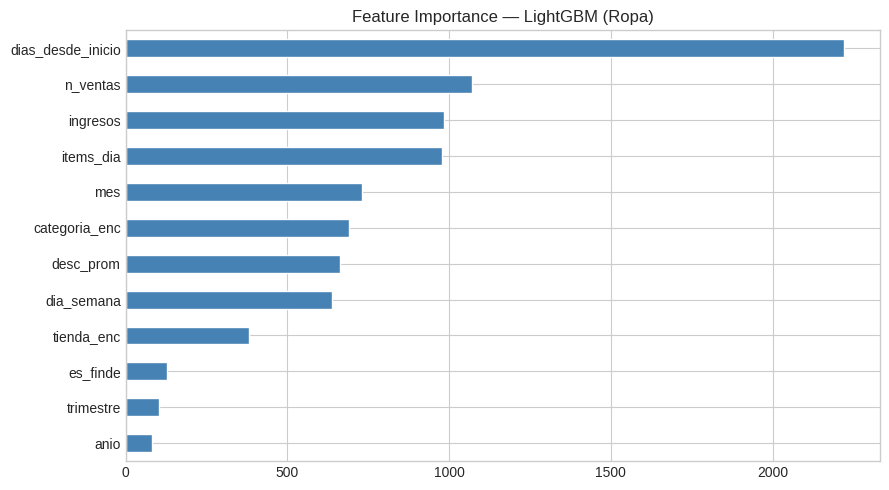

In [15]:
print(f'\n{"Modelo":<22} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 50)
todos = [
    ('Baseline Ridge',  RESULTADOS['baseline']['rmse'], RESULTADOS['baseline']['mae'], RESULTADOS['baseline']['r2']),
    ('Random Forest',   RESULTADOS['RF']['rmse'],        RESULTADOS['RF']['mae'],        RESULTADOS['RF']['r2']),
    ('XGBoost',         RESULTADOS['XGB']['rmse'],       RESULTADOS['XGB']['mae'],       RESULTADOS['XGB']['r2']),
    ('LightGBM',        RESULTADOS['LGBM']['rmse'],      RESULTADOS['LGBM']['mae'],      RESULTADOS['LGBM']['r2']),
    ('Stacking NN',     rmse_meta, mae_meta, r2_meta),
]
for nombre, rmse, mae, r2 in todos:
    print(f'{nombre:<22} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}')
print('=' * 50)

importancias = pd.Series(m_lgbm.feature_importances_, index=FEATURES).sort_values()
importancias.plot(kind='barh', figsize=(9,5), color='steelblue', edgecolor='white')
plt.title('Feature Importance — LightGBM (Ropa)')
plt.tight_layout()
plt.show()

## Preguntas de Reflexion

### 1. Estacionalidad
El pico de mayor **volumen** (unidades) se concentra en **enero y julio** (liquidaciones, hasta 70% descuento). 
Sin embargo, el pico de mayor **ingreso por venta** es **mayo** (Dia de la Madre), donde el precio promedio sube a $133,959 vs $116,276 en semana normal (+15%). 
Esto ilustra que volumen alto ≠ ingreso alto: en liquidacion se vende mas pero a precio mucho menor.

### 2. Feature Importance
`dias_desde_inicio` e `items_dia` dominan el top-5. `temporada_moda` y `es_dia_madre` **no aparecen** porque en la agregacion esas variables no se llevaron al dataset `demanda_diaria`. 
Para capturarlas habria que hacer un join de vuelta con el df original.

### 3. Liquidacion vs Demanda como Target
**Si.** Usar `ingresos` como target capturaria mejor el valor economico real. 
Con `items_dia` el modelo trata igual vender 10 prendas a $200,000 que 10 a $40,000 en liquidacion. 
Para decision de inventario financiero, `ingresos` es superior; para logistica y espacio fisico, `items_dia` es mas directo.

### 4. Modelo unico vs por CC
Un modelo unico tiene poder suficiente gracias a `tienda_enc`, pero modelos por CC probablemente mejorarian el R2 porque 
El Tesoro (precio prom $172K) y Unico Itagui ($86K) tienen perfiles de demanda muy distintos. 
La ganancia en precision debe evaluarse contra el costo de mantener 6 modelos separados.

### 5. ¿Mejoro el Stacking?
La red neuronal (**R2=0.55**) no mejoro sobre RF (**R2=0.60**). Con solo 3 inputs (predicciones de los 3 modelos), la red tiene muy poca informacion adicional. 
El RF ya incorporo la mayor parte de la señal disponible. No hay data leakage — el split temporal lo previene correctamente.